# 08 — Lawyer evaluation of 6 extraction systems

This notebook reads the 20 xlsx evaluation sheets in
`data/08_evaluation_sheets_simple_filled/` (filled by 20 lawyers) and
compares the 6 extraction configurations: 3 models × 2 modes (RAG / Full-doc).

Each sheet has 4 rated sections:
- S1 Kontext sporu — 1-10 score per system (dispute summary quality)
- S2 Odôvodnenie súdu — 1-10 score per system (reasoning summary quality)
- S3 Faktory § 301 — 7 factors × 6 systems with categorical match
  (áno / čiastočne / nie / neviem) vs court's actual factor sentiment
- S4 Halucinácie + Celkový dojem — two 1-10 scores per system

Two questions for the paper:
1. Kvalita extrakcie — combined extraction quality (sections 1, 2, 4.2)
2. Halucinácie — hallucination level (section 4.1)

Bonus: factor agreement rate (section 3) and per-document breakdown.

In [1]:
import openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob

plt.rcParams['figure.dpi'] = 140
plt.rcParams['font.size'] = 10
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

EVAL_DIR = '../data/08_evaluation_sheets_simple_filled'
files = sorted(glob.glob(f'{EVAL_DIR}/eval_*.xlsx'))
print(f'Found {len(files)} evaluation sheets')

# system order matches column 2-7 in S3 / S4 ratings tables
SYSTEMS = ['GPT-4o RAG', 'GPT-4o Full', 'Gemini RAG', 'Gemini Full', 'Qwen 3.5 RAG', 'Qwen 3.5 Full']

# 7 § 301 factors — labels used for plots
FACTORS = ['Dobré mravy', 'Zabezpečovacia funkcia', 'Výška škody',
           'Pomer k istine', 'Správanie dlžníka', 'Kumulácia s úrokom', 'Správanie veriteľa']

# rows where each metric lives (verified consistent across all 20 sheets)
S1_ROWS = list(range(31, 37))   # 'kontext sporu' score 1-10, col 7, 6 systems
S2_ROWS = list(range(42, 48))   # 'odôvodnenie' score 1-10, col 7, 6 systems
S3_RATING_ROWS = [53, 55, 57, 59, 61, 63, 65]  # 7 factor ratings, cols 2-7
S4_HALUC_ROW = 70  # 'halucinácie' (hallucinations) 1-10, cols 2-7
S4_DOJEM_ROW = 71  # 'celkový dojem' (overall impression) 1-10, cols 2-7

Found 20 evaluation sheets


---
## 1. Load all 20 sheets into a long-format DataFrame

One row per (doc, system, metric). Easier to slice and aggregate.

In [2]:
def parse_sheet(path):
    """Extract all 5 metrics + 7 factor ratings from one sheet. Returns list of records."""
    wb = openpyxl.load_workbook(path, data_only=True)
    ws = wb['Evaluácia']
    doc_id = Path(path).stem.replace('eval_', '')  # e.g. '01_43Cob_30_2023'
    records = []

    # S1 + S2: rows 31-36 (S1) and 42-47 (S2), score in col 7
    for i, sys in enumerate(SYSTEMS):
        s1 = ws.cell(row=S1_ROWS[i], column=7).value
        s2 = ws.cell(row=S2_ROWS[i], column=7).value
        haluc = ws.cell(row=S4_HALUC_ROW, column=2 + i).value
        dojem = ws.cell(row=S4_DOJEM_ROW, column=2 + i).value
        rec = {'doc': doc_id, 'system': sys,
               'kontext': s1, 'odovodnenie': s2,
               'halucinacie': haluc, 'dojem': dojem}
        # 7 factor ratings (categorical)
        for f_idx, f_row in enumerate(S3_RATING_ROWS):
            rec[f'factor_{f_idx}'] = ws.cell(row=f_row, column=2 + i).value
        records.append(rec)
    return records

all_records = []
for f in files:
    all_records.extend(parse_sheet(f))

df = pd.DataFrame(all_records)
print(f'Loaded {len(df)} (doc × system) rows')
print(f'Docs: {df["doc"].nunique()}, Systems: {df["system"].nunique()}')
df.head(6)

Loaded 120 (doc × system) rows
Docs: 20, Systems: 6


,doc,system,kontext,odovodnenie,halucinacie,dojem,factor_0,factor_1,factor_2,factor_3,factor_4,factor_5,factor_6
0,01_43Cob_30_2023,GPT-4o RAG,8,8,9,8,áno,čiastočne,áno,áno,čiastočne,áno,áno
1,01_43Cob_30_2023,GPT-4o Full,6,5,5,5,áno,áno,áno,áno,čiastočne,áno,áno
2,01_43Cob_30_2023,Gemini RAG,7,9,9,9,áno,áno,áno,áno,áno,áno,áno
3,01_43Cob_30_2023,Gemini Full,6,5,5,5,áno,áno,áno,áno,čiastočne,áno,áno
4,01_43Cob_30_2023,Qwen 3.5 RAG,7,8,9,7,áno,čiastočne,áno,áno,nie,áno,áno
5,01_43Cob_30_2023,Qwen 3.5 Full,5,5,4,4,áno,čiastočne,áno,nie,čiastočne,áno,áno


In [3]:
# Sanity check: any missing values?
missing = df[['kontext', 'odovodnenie', 'halucinacie', 'dojem']].isna().sum()
print('Missing values per metric:')
print(missing)

# convert to numeric (in case some values are strings)
for col in ['kontext', 'odovodnenie', 'halucinacie', 'dojem']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'\nValue ranges:')
for col in ['kontext', 'odovodnenie', 'halucinacie', 'dojem']:
    print(f'  {col}: min={df[col].min()}, max={df[col].max()}, mean={df[col].mean():.2f}')

Missing values per metric:
kontext        0
odovodnenie    0
halucinacie    0
dojem          0
dtype: int64

Value ranges:
  kontext: min=5, max=9, mean=7.62
  odovodnenie: min=4, max=10, mean=7.95
  halucinacie: min=3, max=10, mean=7.32
  dojem: min=4, max=9, mean=6.97


---
## 2. Aggregate per system (mean across 20 docs)

Build the main comparison table — one row per system, columns are average scores.

In [4]:
agg = df.groupby('system')[['kontext', 'odovodnenie', 'halucinacie', 'dojem']].mean()
agg = agg.reindex(SYSTEMS)

# composite "Kvalita extrakcie" = mean of kontext + odovodnenie + dojem
# (excludes halucinacie — that's its own dimension, not part of quality)
agg['kvalita_extrakcie'] = agg[['kontext', 'odovodnenie', 'dojem']].mean(axis=1)

agg = agg[['kontext', 'odovodnenie', 'dojem', 'kvalita_extrakcie', 'halucinacie']]
agg.style.format('{:.2f}').background_gradient(cmap='Greens', subset=['kontext','odovodnenie','dojem','kvalita_extrakcie']) \
                            .background_gradient(cmap='Greens', subset=['halucinacie'])

,kontext,odovodnenie,dojem,kvalita_extrakcie,halucinacie
system,,,,,
GPT-4o RAG,7.60,7.30,6.70,7.20,7.25
GPT-4o Full,7.45,7.30,6.55,7.10,6.85
Gemini RAG,7.85,8.75,7.65,8.08,7.95
Gemini Full,7.65,8.20,7.20,7.68,7.20
Qwen 3.5 RAG,7.40,8.30,7.15,7.62,7.60
Qwen 3.5 Full,7.80,7.85,6.60,7.42,7.05


---
## 3. Main figure for paper — Kvalita extrakcie & Halucinácie

Two panels:
- (a) Kvalita extrakcie (composite score from kontext + odôvodnenie + dojem)
- (b) Halucinácie (10 = bez halucinácií, 1 = veľa vymyslených). Higher is better.

Both panels point in the same direction (higher = better). RAG vs Full
pairs are grouped per model. Color: RAG = teal, Full = coral.

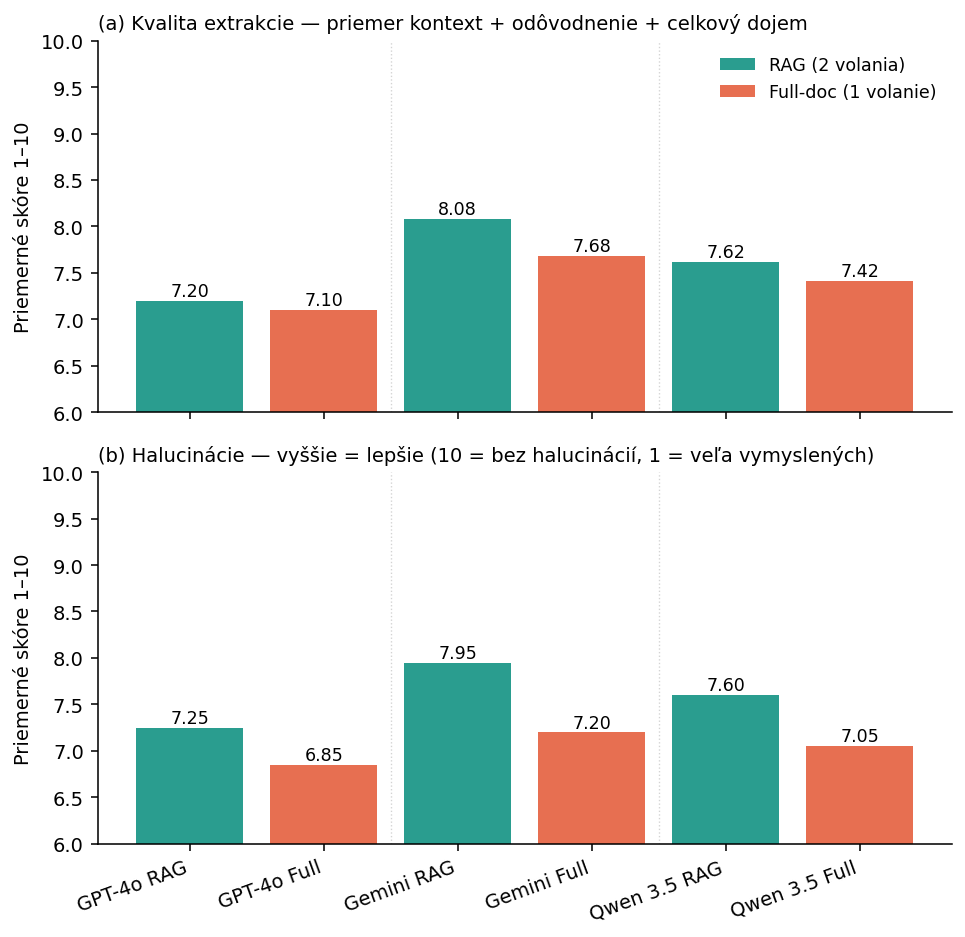

Saved to diagrams/PAPER_obr_extraction_quality.{pdf,png}


In [5]:
RAG_COLOR = '#2a9d8f'   # teal
FULL_COLOR = '#e76f51'  # coral
colors = [RAG_COLOR, FULL_COLOR] * 3

fig, axes = plt.subplots(2, 1, figsize=(7, 6.8), sharex=True)

# Panel A: Kvalita extrakcie
ax = axes[0]
vals = agg['kvalita_extrakcie'].values
bars = ax.bar(range(len(SYSTEMS)), vals, color=colors)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.05, f'{v:.2f}',
            ha='center', fontsize=9)
ax.set_ylabel('Priemerné skóre 1–10')
ax.set_title('(a) Kvalita extrakcie — priemer kontext + odôvodnenie + celkový dojem',
             fontsize=10, loc='left')
ax.set_ylim(6, 10)
for x in [1.5, 3.5]:
    ax.axvline(x, color='lightgray', lw=0.7, ls=':')

# Panel B: Halucinácie — same data, clearer naming.
# Title makes the convention explicit (higher = better); y-axis stays neutral
# (just "Priemerné skóre 1–10" — Slovak label, paper is Slovak) so it parallels Panel A.
ax = axes[1]
vals = agg['halucinacie'].values
bars = ax.bar(range(len(SYSTEMS)), vals, color=colors)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.05, f'{v:.2f}',
            ha='center', fontsize=9)
ax.set_ylabel('Priemerné skóre 1–10')
ax.set_title('(b) Halucinácie — vyššie = lepšie (10 = bez halucinácií, 1 = veľa vymyslených)',
             fontsize=10, loc='left')
ax.set_ylim(6, 10)
for x in [1.5, 3.5]:
    ax.axvline(x, color='lightgray', lw=0.7, ls=':')

ax.set_xticks(range(len(SYSTEMS)))
ax.set_xticklabels(SYSTEMS, rotation=20, ha='right')

# legend (single, top right)
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=RAG_COLOR, label='RAG (2 volania)'),
                Patch(facecolor=FULL_COLOR, label='Full-doc (1 volanie)')]
axes[0].legend(handles=legend_elems, loc='upper right', frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig('../diagrams/PAPER_obr_extraction_quality.pdf', bbox_inches='tight')
plt.savefig('../diagrams/PAPER_obr_extraction_quality.png', dpi=160, bbox_inches='tight')
plt.show()
print('Saved to diagrams/PAPER_obr_extraction_quality.{pdf,png}')

---
## 4. RAG vs Full delta per model

Does RAG actually beat Full-doc per model? This is what the paper claims,
so I want to see it explicitly.

In [6]:
deltas = {}
for m in ['GPT-4o', 'Gemini', 'Qwen 3.5']:
    rag = agg.loc[f'{m} RAG']
    full = agg.loc[f'{m} Full']
    deltas[m] = (rag - full)
delta_df = pd.DataFrame(deltas).T
delta_df.columns = ['Δ kontext', 'Δ odôvodnenie', 'Δ dojem', 'Δ quality', 'Δ hallucinations']

delta_df.style.format('{:+.2f}') \
    .background_gradient(cmap='RdYlGn', vmin=-2, vmax=2)

,Δ kontext,Δ odôvodnenie,Δ dojem,Δ quality,Δ hallucinations
GPT-4o,+0.15,+0.00,+0.15,+0.10,+0.40
Gemini,+0.20,+0.55,+0.45,+0.40,+0.75
Qwen 3.5,-0.40,+0.45,+0.55,+0.20,+0.55


---
## 5. Section 3 — Factor agreement rate per system

For each of 7 § 301 factors, lawyers marked whether system's sentiment matched the court's actual reasoning. Categories: `áno` (full match), `čiastočne` (partial), `nie` (mismatch), `nespomínané`/`neviem` (court did not address it; mostly NaN).

Agreement rate = % of `áno` ratings (treating `čiastočne` as 0.5).

In [7]:
factor_score_map = {'áno': 1.0, 'čiastočne': 0.5, 'nie': 0.0, 'neviem': np.nan, 'nespomínané': np.nan}

factor_cols = [f'factor_{i}' for i in range(7)]
for c in factor_cols:
    df[f'{c}_score'] = df[c].map(factor_score_map)

# average across 20 docs × 7 factors per system
factor_score_cols = [f'factor_{i}_score' for i in range(7)]
agg_factors = df.groupby('system')[factor_score_cols].mean()
agg_factors.columns = FACTORS
agg_factors = agg_factors.reindex(SYSTEMS)

# overall factor agreement rate per system
agg_factors['Priemer'] = agg_factors.mean(axis=1)

print('Faktor agreement rate (1.00 = áno, 0.50 = čiastočne, 0.00 = nie):')
agg_factors.style.format('{:.2f}').background_gradient(cmap='Greens', vmin=0.5, vmax=1.0)

Faktor agreement rate (1.00 = áno, 0.50 = čiastočne, 0.00 = nie):


,Dobré mravy,Zabezpečovacia funkcia,Výška škody,Pomer k istine,Správanie dlžníka,Kumulácia s úrokom,Správanie veriteľa,Priemer
system,,,,,,,,
GPT-4o RAG,0.62,0.62,0.95,0.72,0.66,0.92,0.80,0.76
GPT-4o Full,0.50,0.85,0.72,0.75,0.26,0.89,0.78,0.68
Gemini RAG,0.38,0.62,0.93,0.72,0.58,0.92,0.68,0.69
Gemini Full,0.68,0.85,0.95,0.80,0.47,0.92,0.85,0.79
Qwen 3.5 RAG,0.65,0.70,0.88,0.45,0.22,0.94,0.68,0.65
Qwen 3.5 Full,0.78,0.88,0.88,0.62,0.29,0.89,0.90,0.75


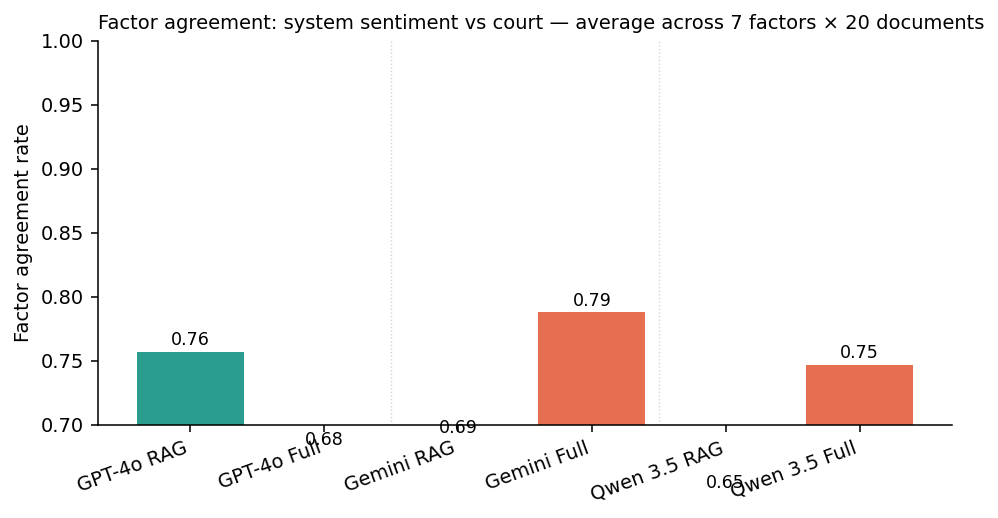

In [8]:
# bar chart of overall factor agreement
fig, ax = plt.subplots(figsize=(7, 3.8))
vals = agg_factors['Priemer'].values
bars = ax.bar(range(len(SYSTEMS)), vals, color=colors)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.005, f'{v:.2f}',
            ha='center', fontsize=9)
ax.set_ylabel('Factor agreement rate')
ax.set_title('Factor agreement: system sentiment vs court — average across 7 factors × 20 documents',
             fontsize=10, loc='left')
ax.set_ylim(0.7, 1.0)
ax.set_xticks(range(len(SYSTEMS)))
ax.set_xticklabels(SYSTEMS, rotation=20, ha='right')
for x in [1.5, 3.5]:
    ax.axvline(x, color='lightgray', lw=0.7, ls=':')
plt.tight_layout()
plt.show()

---
## 6. Per-document heatmap — kvalita extrakcie

Are the scores driven by a few outlier docs, or are they consistent? 20 docs ×
6 systems heatmap of composite quality (kontext + odôvodnenie + dojem).

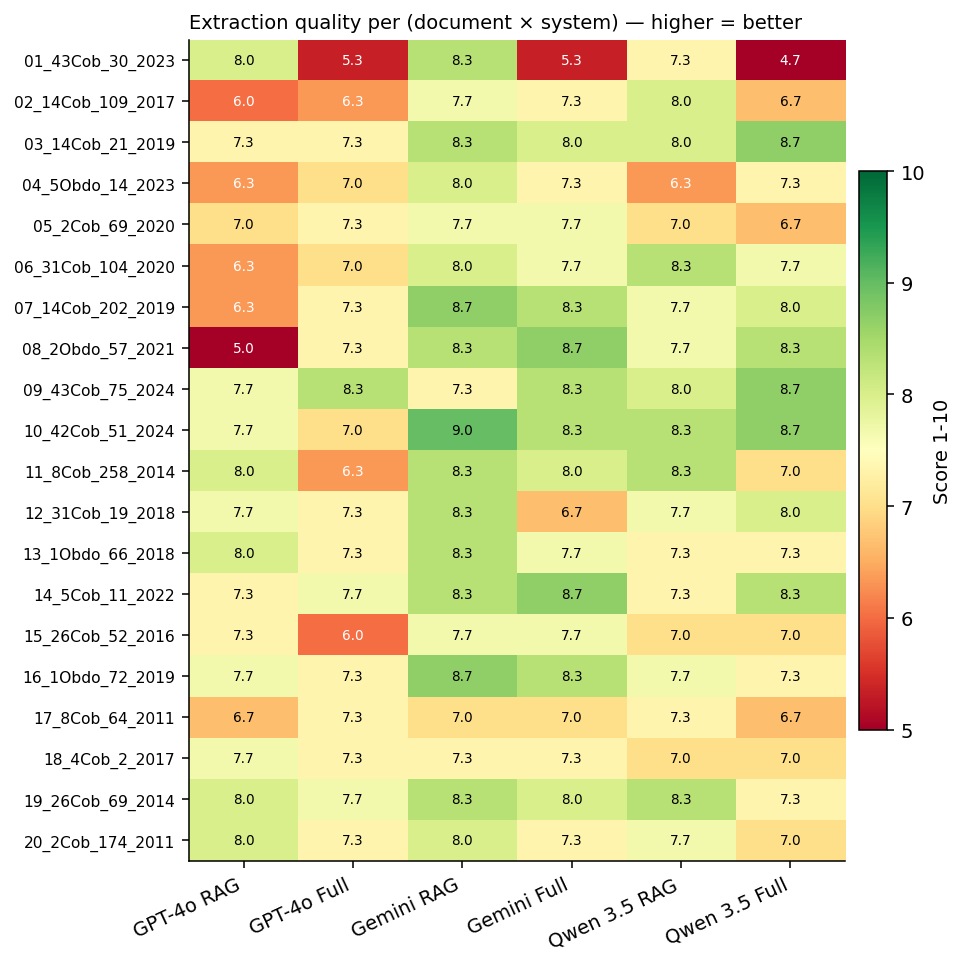

In [9]:
df['kvalita'] = df[['kontext', 'odovodnenie', 'dojem']].mean(axis=1)
heat = df.pivot_table(index='doc', columns='system', values='kvalita')
heat = heat.reindex(columns=SYSTEMS)

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(heat.values, cmap='RdYlGn', aspect='auto', vmin=5, vmax=10)
ax.set_xticks(range(len(SYSTEMS)))
ax.set_xticklabels(SYSTEMS, rotation=25, ha='right')
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index, fontsize=8)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        if pd.notna(v):
            color = 'white' if v < 6.5 else 'black'
            ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=7, color=color)
ax.set_title('Extraction quality per (document × system) — higher = better',
             fontsize=10, loc='left')
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label='Score 1-10')
plt.tight_layout()
plt.show()

---
## 7. Summary — paper numbers

Print the key numbers in plain text for easy copy into the paper.

In [10]:
print('=' * 70)
print('FINAL NUMBERS FOR PAPER (averaged across 20 docs)')
print('=' * 70)
print(f'\n{"System":<16} {"Quality":<10} {"Hallucinations":<14} {"Factors":<10}')
print('-' * 50)
for s in SYSTEMS:
    k = agg.loc[s, 'kvalita_extrakcie']
    h = agg.loc[s, 'halucinacie']
    f = agg_factors.loc[s, 'Priemer']
    print(f'{s:<16} {k:<10.2f} {h:<12.2f} {f:<10.2f}')

print('\n' + '=' * 70)
print('RAG vs Full delta per model')
print('=' * 70)
for m in ['GPT-4o', 'Gemini', 'Qwen 3.5']:
    dk = agg.loc[f'{m} RAG', 'kvalita_extrakcie'] - agg.loc[f'{m} Full', 'kvalita_extrakcie']
    dh = agg.loc[f'{m} RAG', 'halucinacie'] - agg.loc[f'{m} Full', 'halucinacie']
    df_ = agg_factors.loc[f'{m} RAG', 'Priemer'] - agg_factors.loc[f'{m} Full', 'Priemer']
    print(f'{m:<10}  Δ quality: {dk:+.2f},  Δ hallucinations: {dh:+.2f},  Δ factors: {df_:+.2f}')

FINAL NUMBERS FOR PAPER (averaged across 20 docs)

System           Quality    Hallucinations Factors   
--------------------------------------------------
GPT-4o RAG       7.20       7.25         0.76      
GPT-4o Full      7.10       6.85         0.68      
Gemini RAG       8.08       7.95         0.69      
Gemini Full      7.68       7.20         0.79      
Qwen 3.5 RAG     7.62       7.60         0.65      
Qwen 3.5 Full    7.42       7.05         0.75      

RAG vs Full delta per model
GPT-4o      Δ quality: +0.10,  Δ hallucinations: +0.40,  Δ factors: +0.08
Gemini      Δ quality: +0.40,  Δ hallucinations: +0.75,  Δ factors: -0.10
Qwen 3.5    Δ quality: +0.20,  Δ hallucinations: +0.55,  Δ factors: -0.10
